In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

file = '/Users/jonzimmerman/Desktop/Data Projects/AllTrails/synthetic_hiking_reviews.csv'
df = pd.read_csv(file)
print(df.shape)

(4112, 10)


In [2]:
df.head()

,review_id,trail_name,state,latitude,longitude,difficulty,elevation_gain_ft,rating,date,review_text
0,1,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,2.81,2021-06-23,"This was a tough one, definitely worth the eff..."
1,2,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,4.19,2023-05-21,"This was a tough climb, no doubt about it – th..."
2,3,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,2.02,2022-07-09,"This was a tough one, no doubt about it. The c..."
3,4,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,2.81,2023-08-23,"This was a tough one, definitely worth the eff..."
4,5,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,3.95,2023-02-25,"This was a tough one, definitely worth the eff..."


### Daily and Monthly Plots

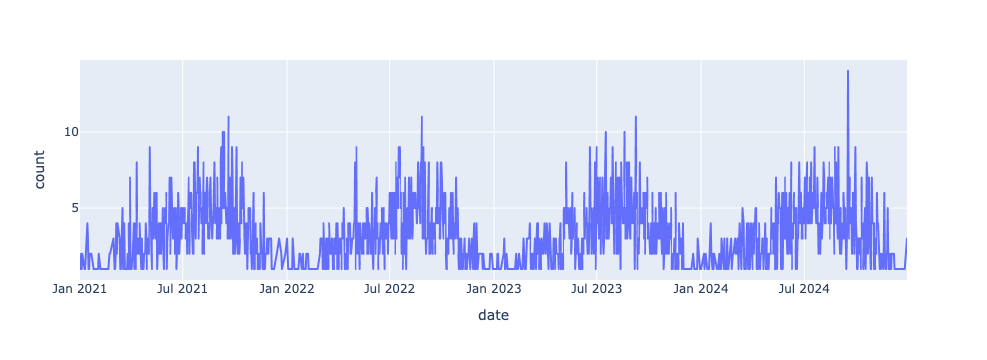

In [3]:
df_daily_counts = df.groupby("date").size().reset_index(name="count")
px.line(df_daily_counts, x="date", y="count")

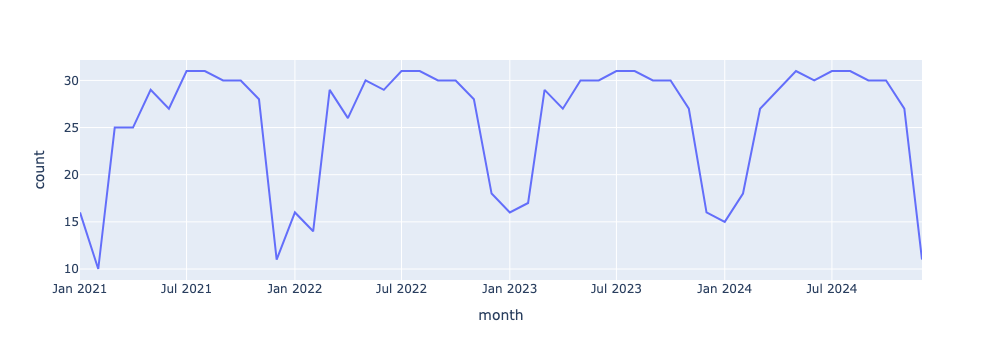

In [4]:
df_daily_counts["month"] = pd.to_datetime(df_daily_counts["date"]).dt.to_period("M").dt.to_timestamp()
df_monthly_counts = df_daily_counts.groupby("month").size().reset_index(name="count")
px.line(df_monthly_counts, x = 'month', y = 'count')

In [5]:
df_monthly_counts = df.groupby(["date", "rating"]).size().reset_index(name="count")
df_monthly_counts["month"] = pd.to_datetime(df_monthly_counts["date"]).dt.to_period("M").dt.to_timestamp()
df_monthly_counts = df_monthly_counts.groupby(["month", "rating"]).size().reset_index(name="count")


df_monthly_counts["weighted_rating"] = df_monthly_counts["rating"] * df_monthly_counts["count"]

df_monthly_summary = df_monthly_counts.groupby("month").agg(
    review_count=("count", "sum"),
    total_rating=("weighted_rating", "sum")
).reset_index()

df_monthly_summary["avg_rating"] = df_monthly_summary["total_rating"] / df_monthly_summary["review_count"]
df_monthly_summary.head()


,month,review_count,total_rating,avg_rating
0,2021-01-01,25,95.05,3.802000
1,2021-02-01,13,49.72,3.824615
2,2021-03-01,56,197.13,3.520179
3,2021-04-01,59,202.84,3.437966
4,2021-05-01,99,352.99,3.565556


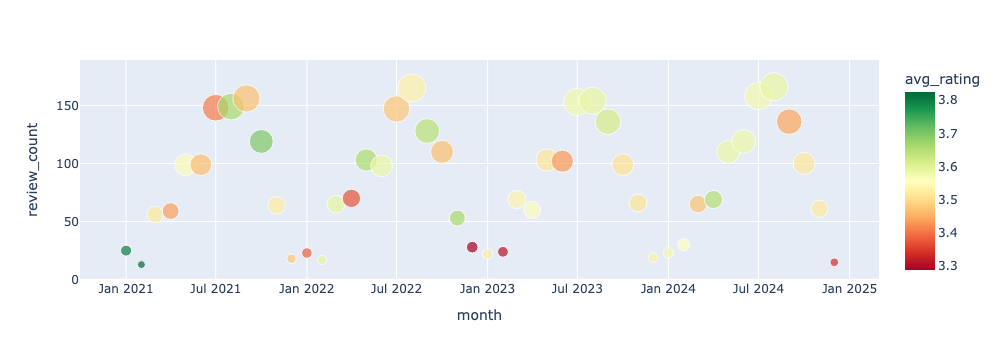

In [6]:
px.scatter(
    df_monthly_summary,
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

### Plot Monthly Reviews by Trail

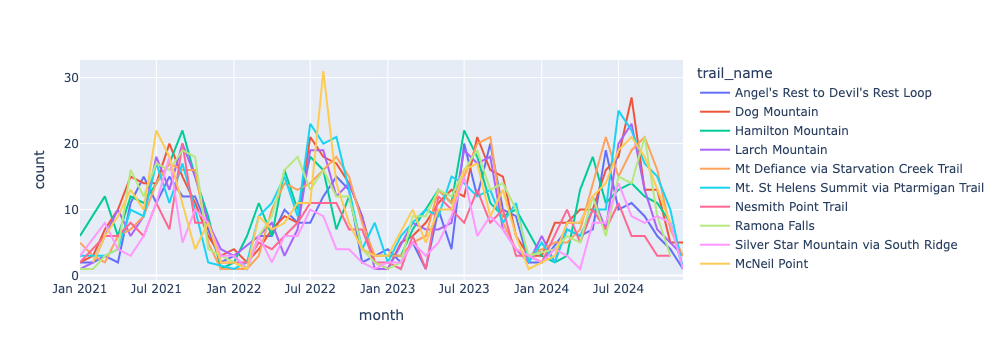

In [7]:
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").dt.to_timestamp()
df_monthly_trail_counts = df.groupby(["month", "trail_name"]).size().reset_index(name="count")
px.line(df_monthly_trail_counts, x = 'month', y = 'count', color = 'trail_name')

In [8]:
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").dt.to_timestamp()
df_monthly_trail_counts = df.groupby(["month", "trail_name", "rating"]).size().reset_index(name="count")
df_monthly_trail_counts["weighted_rating"] = df_monthly_trail_counts["rating"] * df_monthly_trail_counts["count"]

df_monthly_trail_summary = df_monthly_trail_counts.groupby(["month","trail_name"]).agg(
    review_count=("count", "sum"),
    total_rating=("weighted_rating", "sum")
).reset_index()

df_monthly_trail_summary["avg_rating"] = df_monthly_trail_summary["total_rating"] / df_monthly_trail_summary["review_count"]
df_monthly_trail_summary.head()

,month,trail_name,review_count,total_rating,avg_rating
0,2021-01-01,Angel's Rest to Devil's Rest Loop,2,5.40,2.700000
1,2021-01-01,Dog Mountain,2,8.08,4.040000
2,2021-01-01,Hamilton Mountain,6,23.30,3.883333
3,2021-01-01,Larch Mountain,1,4.49,4.490000
4,2021-01-01,Mt Defiance via Starvation Creek Trail,5,20.32,4.064000


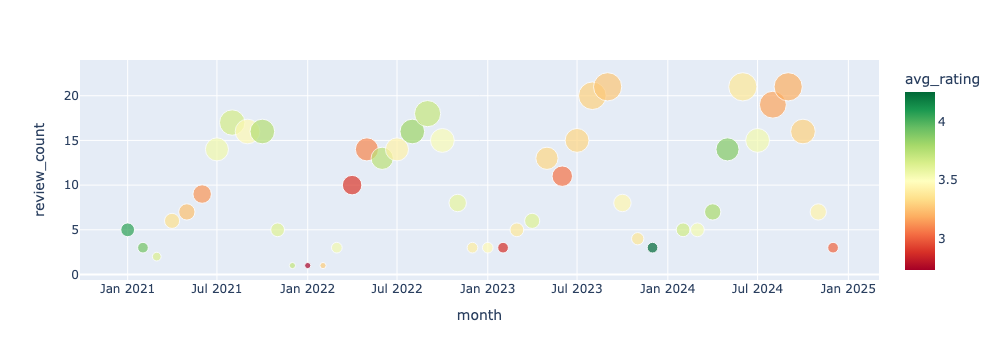

In [9]:
px.scatter(
    df_monthly_trail_summary[df_monthly_trail_summary['trail_name']=='Mt Defiance via Starvation Creek Trail'],
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

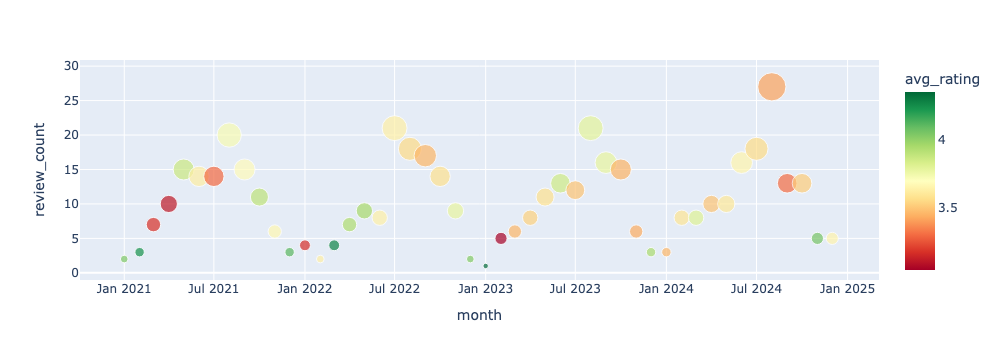

In [10]:
px.scatter(
    df_monthly_trail_summary[df_monthly_trail_summary['trail_name']=='Dog Mountain'],
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

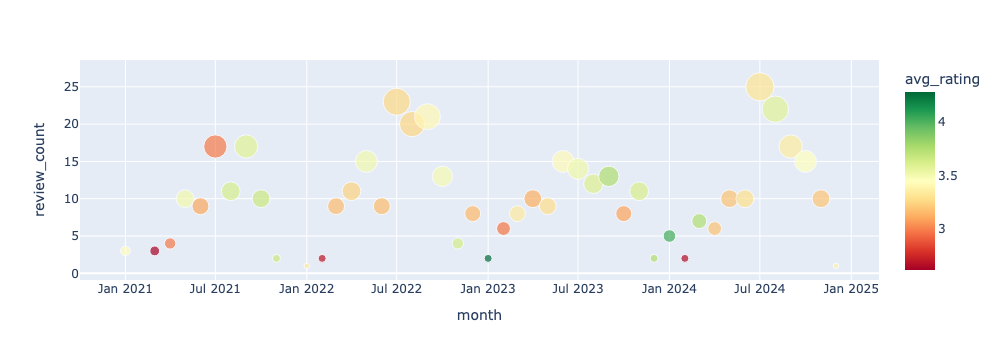

In [11]:
px.scatter(
    df_monthly_trail_summary[df_monthly_trail_summary['trail_name']=='Mt. St Helens Summit via Ptarmigan Trail'],
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

### Bear Flag

In [42]:
df['bear_flag'] = df['review_text'].str.contains('bear', case=False, na=False)

non_bear_bear_references = ['bear grass','beargrass','bearings','bearable', 'bear spray', 'no bear',
                           "see any bears", "encounter any bears","bears – thankfully, we didn't spot any"]
df['non_bear_bear_references'] = df['review_text'].str.contains('|'.join(non_bear_bear_references), case=False, na=False)

bear_reviews = df[(df['bear_flag']==True) & (df['non_bear_bear_references']==False)].reset_index()
bear_reviews.shape

(41, 14)

In [51]:
bear_reviews['review_text'][14]

'Wow, what a climb! This Mt. Defiance trail is seriously challenging – that 5177 feet of elevation gain really hits you. We were lucky with the weather, it was beautiful and sunny, but there was still plenty of snow on the ground which made footing tricky. Sadly, we encountered a bear near the waterfalls, so definitely be aware and make noise!'

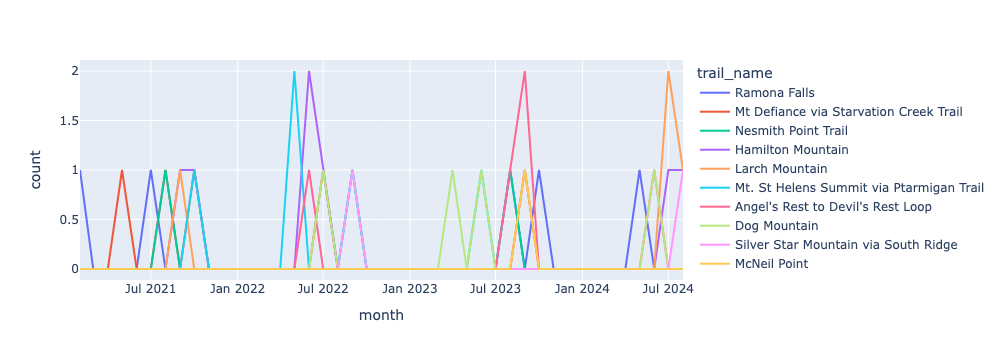

In [61]:
monthly_bear = bear_reviews.groupby(["month", "trail_name"]).size().reset_index(name="count")
all_months = pd.date_range(monthly_bear["month"].min(), monthly_bear["month"].max(),freq="MS")
all_trails = monthly_bear["trail_name"].unique()

full_index = pd.MultiIndex.from_product(
    [all_months, all_trails],
    names=["month", "trail_name"]
)

monthly_bear_chart = monthly_bear.set_index(["month", "trail_name"]).reindex(full_index, fill_value=0).reset_index()

px.line(monthly_bear_chart, x = 'month', y = 'count', color = 'trail_name')

In [64]:
monthly_bear['trail_name'].value_counts()

trail_name
Hamilton Mountain                           6
Ramona Falls                                5
Mt Defiance via Starvation Creek Trail      5
Mt. St Helens Summit via Ptarmigan Trail    4
Angel's Rest to Devil's Rest Loop           4
Dog Mountain                                4
Nesmith Point Trail                         3
Larch Mountain                              3
Silver Star Mountain via South Ridge        2
McNeil Point                                1
Name: count, dtype: int64

In [67]:
monthly_bear['quarter'] = 'Q' + monthly_bear['month'].dt.quarter.astype(str)
monthly_bear['quarter'].value_counts()

quarter
Q3    22
Q2    10
Q4     4
Q1     1
Name: count, dtype: int64

In [69]:
monthly_bear['month2'] = 'M' + monthly_bear['month'].dt.month.astype(str)
monthly_bear['month2'].value_counts()

month2
M8     8
M9     8
M7     6
M6     6
M10    4
M5     3
M2     1
M4     1
Name: count, dtype: int64